In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#synthetic data
from sklearn.datasets import make_blobs

In [121]:
X,y = make_blobs(n_samples=1000,centers=6, n_features=2)

In [123]:
X

array([[ 4.35543494, -8.42223493],
       [ 7.82858242,  3.60958569],
       [ 7.28401598,  4.10408564],
       ...,
       [ 3.27520688,  7.26066716],
       [-4.04996446, -1.89484359],
       [ 7.22109018,  3.44681389]])

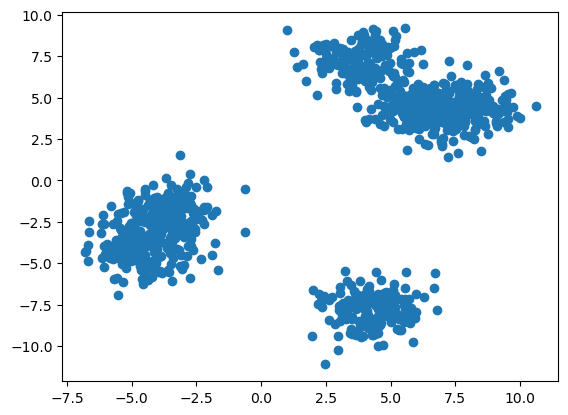

In [125]:
plt.scatter(X[:,0],X[:,1])

In [127]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [129]:
from sklearn.preprocessing import StandardScaler

In [131]:
scaler =  StandardScaler()

In [133]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [135]:
from sklearn.cluster import KMeans

In [137]:
#Ellbow method to find k value
wcss=[]

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++',)
    kmeans.fit_transform(X_train_scaled)
    wcss.append(kmeans.inertia_)

C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

In [139]:
wcss

[1500.0000000000007,
 444.5059607358629,
 135.101011680367,
 70.42356298931463,
 56.263005548178874,
 46.05412431302357,
 42.5260674949321,
 39.13509606013798,
 35.69050713780185,
 33.061485675743306]

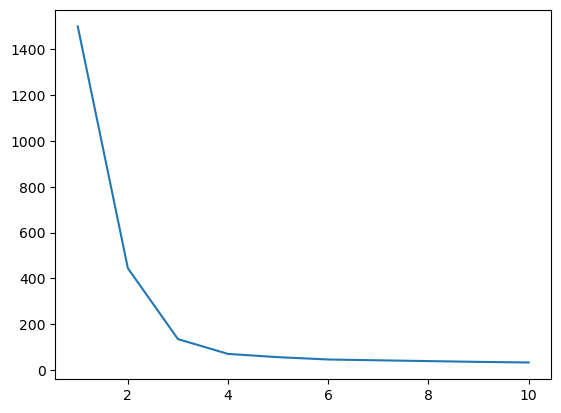

In [141]:
plt.plot(range(1,11),wcss)

In [151]:
kmeans = KMeans(n_clusters=4,init='k-means++',)

In [153]:
kmeans.fit_predict(X_train_scaled)

C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([0, 2, 2, 0, 0, 3, 1, 3, 2, 0, 3, 3, 0, 1, 1, 3, 1, 3, 2, 1, 0, 2,
       2, 2, 0, 3, 3, 0, 3, 2, 2, 0, 3, 2, 2, 0, 2, 0, 0, 1, 0, 2, 1, 3,
       1, 3, 1, 0, 3, 0, 0, 3, 2, 3, 1, 1, 1, 1, 1, 0, 0, 3, 0, 3, 2, 0,
       1, 2, 1, 1, 0, 1, 1, 1, 2, 3, 1, 2, 3, 0, 3, 1, 1, 0, 2, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 2, 0, 1, 2, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 3, 1, 2, 0, 0, 3, 3, 3, 0, 0, 0, 1, 0, 0, 3, 1, 0, 3, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 3, 2, 0, 1, 1, 1, 2, 1, 1, 3, 1, 2, 3, 0,
       1, 1, 3, 2, 2, 1, 3, 3, 3, 3, 1, 2, 2, 3, 3, 0, 2, 2, 1, 3, 2, 1,
       0, 1, 0, 0, 1, 1, 3, 2, 0, 1, 1, 0, 2, 1, 2, 3, 2, 3, 0, 3, 0, 2,
       0, 3, 1, 1, 0, 3, 1, 0, 2, 3, 0, 0, 1, 1, 1, 0, 1, 2, 3, 1, 3, 2,
       2, 0, 1, 1, 3, 2, 0, 2, 0, 1, 1, 0, 3, 3, 2, 1, 3, 3, 2, 0, 3, 0,
       0, 3, 2, 0, 1, 2, 1, 1, 2, 2, 0, 1, 3, 0, 3, 3, 2, 0, 3, 0, 2, 2,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 2, 1, 1, 3, 3, 2, 1, 1, 1,
       1, 0, 2, 1, 3, 3, 3, 1, 3, 2, 0, 1, 0, 2, 3,

In [155]:
y_pred = kmeans.predict(X_test_scaled)

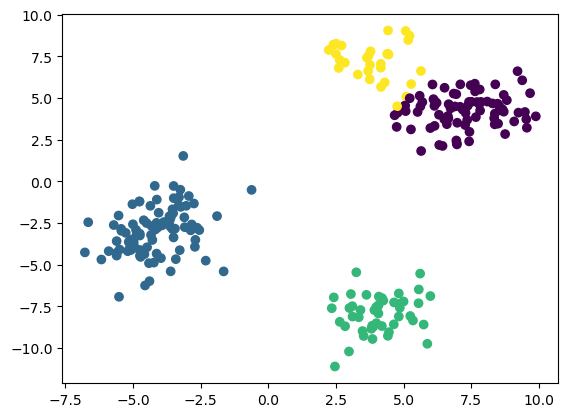

In [157]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [159]:
#knee locator
from kneed import KneeLocator

In [169]:
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [171]:
kl.elbow

3

In [173]:
#silhoutte scoring
from sklearn.metrics import silhouette_score

In [191]:
silhouette_coff = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X=X_train_scaled,labels=kmeans.labels_,metric='euclidean')
    silhouette_coff.append(score)
    print(kmeans.labels_)

C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

[1 0 0 1 1 1 0 1 0 1 1 1 1 0 0 1 0 1 0 0 1 0 0 0 1 1 1 1 1 0 0 1 1 0 0 1 0
 1 1 0 1 0 0 1 0 1 0 1 1 1 1 1 0 1 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 0 1 0 0 0
 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 1 1 0 0 0 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1
 0 0 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 0 1 1 1 0 1 1 0 1 0 0 0 0 0
 0 1 0 0 1 1 0 0 1 0 0 0 1 1 1 1 0 0 0 1 1 1 0 0 0 1 0 0 1 0 1 1 0 0 1 0 1
 0 0 1 0 0 0 1 0 1 1 1 1 0 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 1 0 0 1 0 1 0 0 1
 0 0 1 0 1 0 1 0 0 1 1 1 0 0 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 1 0 1 1 1 1 0
 1 1 1 0 0 0 1 0 0 1 1 0 1 1 1 1 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 1 1 0 1 0
 1 0 1 0 1 1 1 1 1 0 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0 1 0 1 1 0 1
 0 1 1 0 1 1 1 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 1 0 0 0
 0 0 1 0 0 1 1 1 1 0 0 0 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 1 1 0 1 1 0 0 1 1 1
 0 0 1 0 0 1 0 0 1 0 0 1 0 1 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 0 0 1 1 1 0 0 0
 1 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 0 0 0 1 1 1 1 1 1 1 0
 0 1 1 1 1 0 1 1 1 1 1 1 

C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


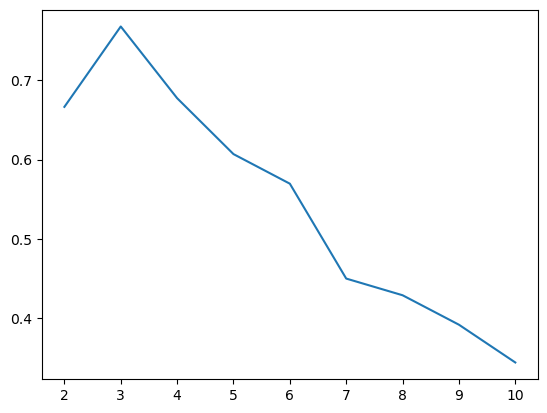

In [194]:
plt.plot(range(2,11),silhouette_coff)